In [ ]:
import sys
sys.path.insert(0, '../') # Trick to import code from parent folder
import cmip6_archive as ca
import numpy as np
import datetime
import xarray as xr

import matplotlib.pyplot as plt
from cartopy import crs as ccrs
import colormaps as cmaps
from plot_utils import plot_panel

# Figure S4
### Growing-season climatology of reference evapotranspiration (ETos) from the historical simulations of the eight CMIP6 models
Climatological means were calculated over 1981–2000.

In [ ]:
def get_growing_season_mask(da: xr.DataArray):
    """Boolean mask (lat, time),  True during growing season. da must have a 'lat' dimension."""
    return (
        ((da.lat >= 0) & (da.time.dt.month.isin([4, 5, 6, 7, 8, 9, 10]))) | # NH: April to October
        ((da.lat < 0) & (da.time.dt.month.isin([1, 2, 3, 4, 10, 11, 12]))) # SH: October to April
    )

def growing_season_mean(da: xr.DataArray):
    """Computes the mean of ds[var] over the growing season as a numpy array"""
    mask = get_growing_season_mask(da)
    gs_mean = da.where(mask).mean(dim='time')
    return gs_mean

In [16]:
BASELINE_YEARS = slice('1981', '2000')

model_et0_gs = {}
for model in ca.MODELS:
    print(f"Processing {model}...")

    # Find growing-season ET0 climatology
    ds = ca.ET0_ARCHIVE.open(model=model, exp='historical').sel(time=BASELINE_YEARS)
    mean_et0_gs = growing_season_mean(ds['ET0']).rename("mean_et0_gs")

    mean_et0_gs.attrs = {"units": "mm day-1",
                        "long_name": "growing-season climatology of ET0 for the historical experiment",
                        "source_id": model}

    # Mask out grid cells with < 5% land
    land_area_fraction = ca.LAND_MASKS_ARCHIVE.open(model=model, exp='piControl')['sftlf']
    mask = (land_area_fraction >= 5).values
    mean_et0_gs = mean_et0_gs.where(mask)
    
    # Add to dict
    model_et0_gs[model] = mean_et0_gs.load()

print(f"✅ Calculated growing-season climatology of ET0 for {len(ca.MODELS)} models")

Processing IPSL-CM6A-LR...
Processing MIROC6...
Processing MRI-ESM2-0...
Processing NorESM2-LM...
Processing NorESM2-MM...
Processing MPI-ESM1-2-HR...
Processing MPI-ESM1-2-LR...
Processing UKESM1-0-LL...
✅ Calculated growing-season climatology of ET0 for 8 models


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/wor

  ✓ png/FigureS4.png
  ✓ pdf/FigureS4.pdf


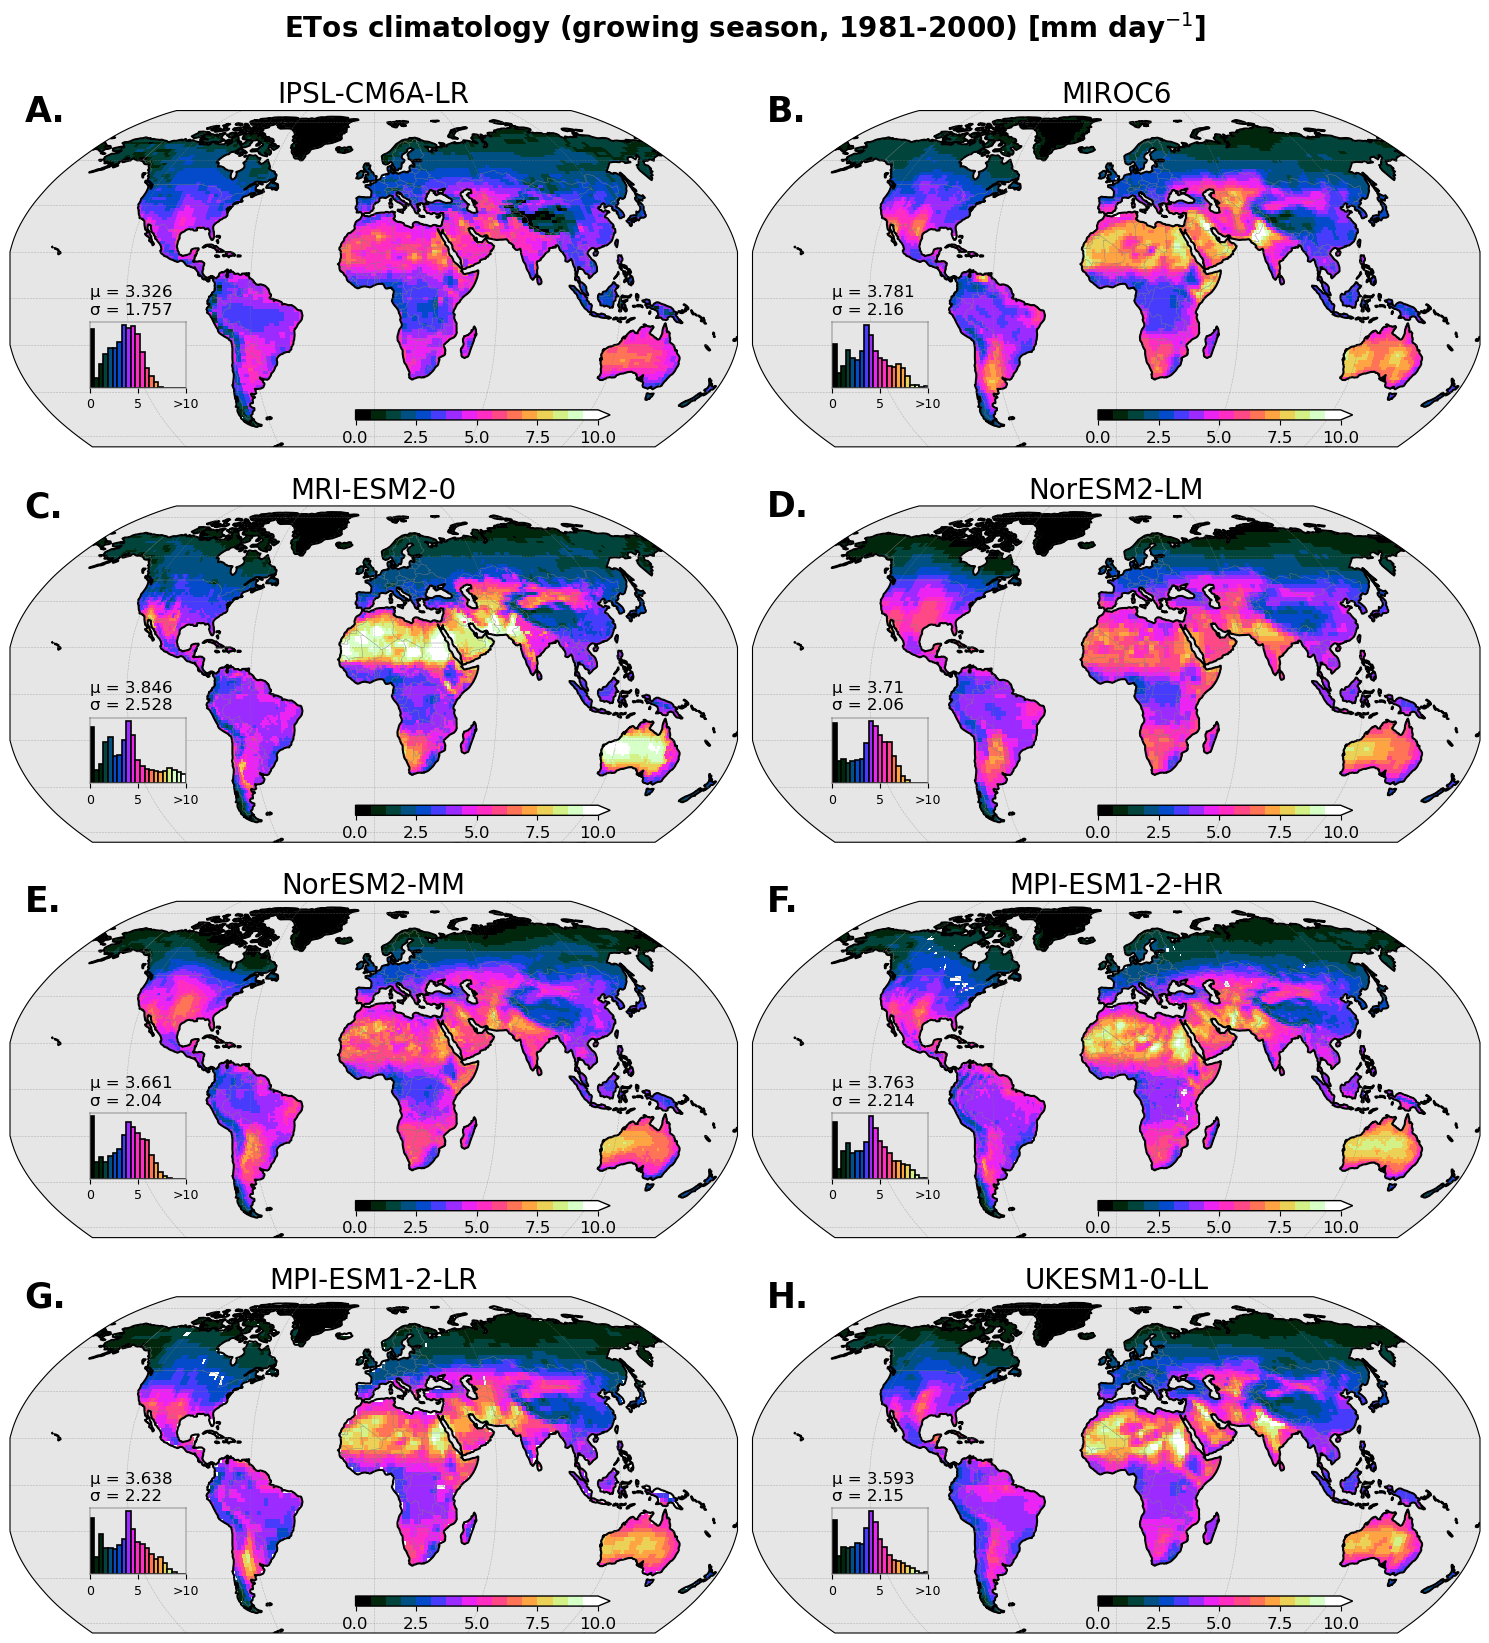

In [17]:
#  4x2 subplot
fig, axes = plt.subplots(
    4, 2,
    figsize=(15, 17),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

CMAP = cmaps.cubehelix3_16
VMIN, VMAX = 0, 10

labels = ["A.", "B.", "C.", "D.", "E.", "F.", "G.", "H."]

for i, label, model in zip(np.arange(8), labels, ca.MODELS):
    plot_panel(
        axes[i],
        model_et0_gs[model],
        title=model,
        vmin=VMIN,
        vmax=VMAX,
        cmap=CMAP,
        extend="max", 
        label=label,
        anom_type="absolute",
    )

suptitle = r"ETos climatology (growing season, 1981-2000) [mm day$^{-1}$]" + "\n"
fig.suptitle(suptitle, fontsize=20, fontweight="bold")
plt.tight_layout()

# Save as png and pdf
for ext in ["png", "pdf"]:
        filename = f"{ext}/FigureS4.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")

plt.show()